# AceIQ — 02 Player Clustering by Surface

## Goal
Three separate K-Means clusterings per surface (Hard / Clay / Grass).
Same player can have different archetype on different surfaces.

**Example:**
- Nadal on Clay = Defender
- Nadal on Hard = All-Court
- Federer on Grass = Aggressive / Serve & Volley

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import glob

df = pd.read_parquet('/content/drive/MyDrive/AceIQ/data/all_matches_2000_2024.parquet')
print(f"Shape: {df.shape}")

Mounted at /content/drive
Shape: (644990, 49)


In [5]:
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2000-301,Auckland,Hard,32,A,20000110,1,103163,1.0,None,...,55.0,39.0,29.0,17.0,4.0,7.0,11.0,1612.0,63.0,595.0
1,2000-301,Auckland,Hard,32,A,20000110,2,102607,NaN,Q,...,32.0,25.0,18.0,12.0,3.0,6.0,211.0,157.0,49.0,723.0
2,2000-301,Auckland,Hard,32,A,20000110,3,103252,NaN,None,...,33.0,20.0,7.0,8.0,7.0,11.0,48.0,726.0,59.0,649.0
3,2000-301,Auckland,Hard,32,A,20000110,4,103507,7.0,None,...,43.0,29.0,14.0,10.0,6.0,8.0,45.0,768.0,61.0,616.0
4,2000-301,Auckland,Hard,32,A,20000110,5,102103,NaN,Q,...,46.0,34.0,18.0,12.0,5.0,9.0,167.0,219.0,34.0,873.0


In [6]:
year = pd.to_datetime(df['tourney_date'].astype(str), format='%Y%m%d').dt.year

winner_df = pd.DataFrame({
    'player_id': df['winner_id'],
    'player_name': df['winner_name'],
    'year': year,
    'ace': df['w_ace'],
    'df': df['w_df'],
    'svpt': df['w_svpt'],
    '1stIn': df['w_1stIn'],
    '1stWon': df['w_1stWon'],
    '2ndWon': df['w_2ndWon'],
    'bpSaved': df['w_bpSaved'],
    'bpFaced': df['w_bpFaced'],
})

loser_df = pd.DataFrame({
    'player_id': df['loser_id'],
    'player_name': df['loser_name'],
    'year': year,
    'ace': df['l_ace'],
    'df': df['l_df'],
    'svpt': df['l_svpt'],
    '1stIn': df['l_1stIn'],
    '1stWon': df['l_1stWon'],
    '2ndWon': df['l_2ndWon'],
    'bpSaved': df['l_bpSaved'],
    'bpFaced': df['l_bpFaced'],
})

In [7]:
winner_df['surface'] = df['surface'].values
loser_df['surface'] = df['surface'].values

# Combine winner and loser stats
all_players = pd.concat([winner_df, loser_df], ignore_index=True)

# Calculate rates
all_players['ace_rate'] = all_players['ace'] / all_players['svpt']
all_players['df_rate'] = all_players['df'] / all_players['svpt']
all_players['1stIn_rate'] = all_players['1stIn'] / all_players['svpt']
all_players['1stWon_rate'] = all_players['1stWon'] / all_players['1stIn']
all_players['2ndWon_rate'] = all_players['2ndWon'] / (all_players['svpt'] - all_players['1stIn'])
all_players['bpSaved_rate'] = all_players['bpSaved'] / all_players['bpFaced'].replace(0, 1)

all_players = all_players.replace([np.inf, -np.inf], np.nan)

print(f"Shape: {all_players.shape}")

# Combine winner and loser stats
all_players = pd.concat([winner_df, loser_df], ignore_index=True)

# Calculate rates (avoid division by zero)
all_players['ace_rate'] = all_players['ace'] / all_players['svpt']
all_players['df_rate'] = all_players['df'] / all_players['svpt']
all_players['1stIn_rate'] = all_players['1stIn'] / all_players['svpt']
all_players['1stWon_rate'] = all_players['1stWon'] / all_players['1stIn']
all_players['2ndWon_rate'] = all_players['2ndWon'] / (all_players['svpt'] - all_players['1stIn'])
all_players['bpSaved_rate'] = all_players['bpSaved'] / all_players['bpFaced'].replace(0, 1)

print(f"Shape: {all_players.shape}")
print(all_players[['ace_rate', 'df_rate', '1stIn_rate', '1stWon_rate', '2ndWon_rate', 'bpSaved_rate']].describe())

Shape: (1289980, 18)
Shape: (1289980, 18)
            ace_rate        df_rate     1stIn_rate    1stWon_rate  \
count  368927.000000  368927.000000  368927.000000  368920.000000   
mean        0.066903       0.040682       0.609043       0.699464   
std         0.056927       0.031130       0.083761       0.108833   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.025000       0.018519       0.553571       0.631579   
50%         0.053571       0.035714       0.609195       0.703704   
75%         0.093750       0.056818       0.666667       0.774194   
max         1.000000       0.666667       1.000000       1.000000   

        2ndWon_rate   bpSaved_rate  
count  3.688610e+05  369010.000000  
mean            inf       0.542841  
std             NaN       0.275264  
min    0.000000e+00       0.000000  
25%    4.242424e-01       0.400000  
50%    5.000000e-01       0.571429  
75%    5.800000e-01       0.714286  
max             inf       1.000000  


In [10]:
# Fix inf values
all_players = all_players.replace([np.inf, -np.inf], np.nan)

# Group by player + year
stats_cols = ['ace_rate', 'df_rate', '1stIn_rate', '1stWon_rate', '2ndWon_rate', 'bpSaved_rate']

player_stats = all_players.groupby(
    ['player_id', 'player_name', 'year', 'surface']
)[stats_cols].mean().reset_index()

player_stats = player_stats.dropna()

print(f"Shape: {player_stats.shape}")
player_stats.head()

Shape: (38506, 10)


,player_id,player_name,year,surface,ace_rate,df_rate,1stIn_rate,1stWon_rate,2ndWon_rate,bpSaved_rate
2,100644,Alexander Zverev,2011,Hard,0.000000,0.066667,0.533333,0.375000,0.476190,0.166667
5,100644,Alexander Zverev,2013,Clay,0.026709,0.110577,0.450321,0.519231,0.271515,0.410714
6,100644,Alexander Zverev,2013,Hard,0.066915,0.057710,0.620395,0.769017,0.510446,0.731481
7,100644,Alexander Zverev,2014,Clay,0.047700,0.051825,0.555254,0.634459,0.486217,0.576989
8,100644,Alexander Zverev,2014,Hard,0.087652,0.048431,0.586784,0.710013,0.520809,0.594728


In [11]:
df_hard = player_stats[player_stats['surface'] == 'Hard']
df_grass = player_stats[player_stats['surface'] == 'Grass']
df_clay = player_stats[player_stats['surface'] == 'Clay']

In [12]:
df_hard_norm = df_hard.copy()
df_grass_norm = df_grass.copy()
df_clay_norm = df_clay.copy()


for col in stats_cols:
  df_hard_norm[col] = df_hard.groupby('year')[col].rank(pct=True)
  df_grass_norm[col] = df_grass.groupby('year')[col].rank(pct=True)
  df_clay_norm[col] = df_clay.groupby('year')[col].rank(pct=True)

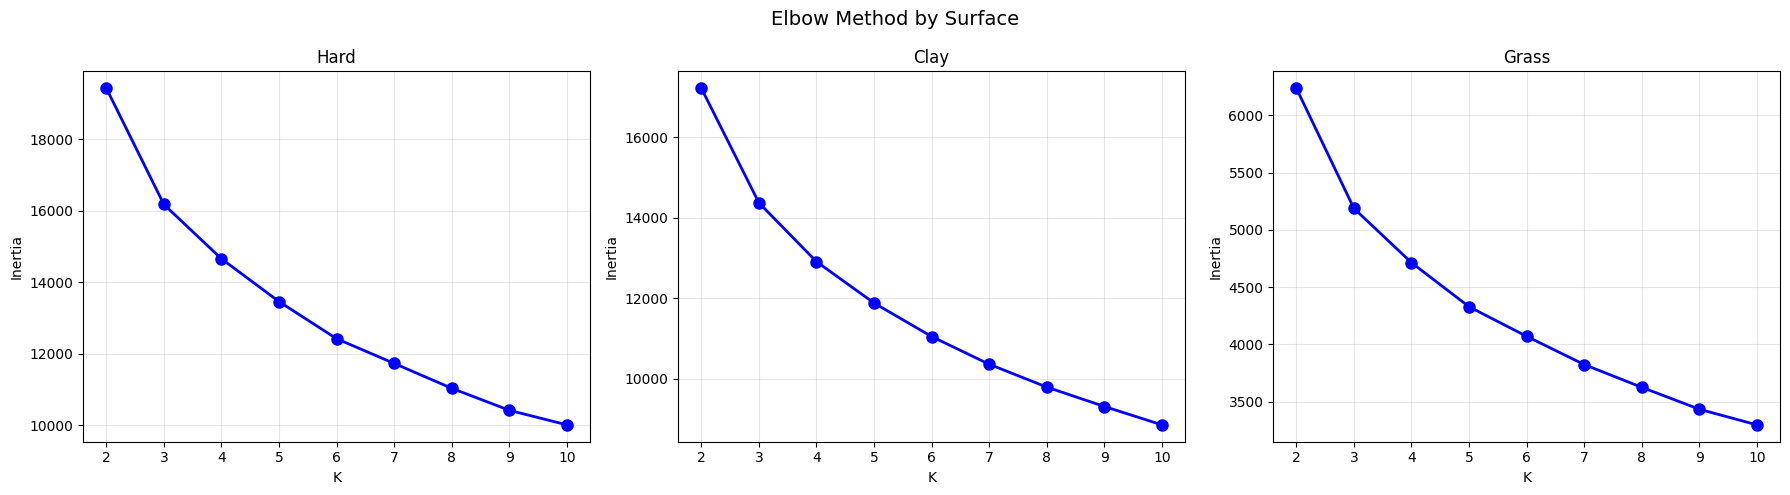

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cluster_features = ['ace_rate', 'df_rate', '1stIn_rate', '1stWon_rate', '2ndWon_rate', 'bpSaved_rate']
K_range = range(2, 11)
surfaces = {'Hard': df_hard_norm, 'Clay': df_clay_norm, 'Grass': df_grass_norm}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Elbow Method by Surface', fontsize=14)

scalers = {}
X_scaled_dict = {}

for ax, (surface_name, data) in zip(axes, surfaces.items()):
    # Take latest year per player
    latest = data.sort_values('year').groupby('player_id').last().reset_index()

    X = latest[cluster_features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scalers[surface_name] = scaler
    X_scaled_dict[surface_name] = (X_scaled, latest)

    inertias = []
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)

    ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    ax.set_title(f'{surface_name}')
    ax.set_xlabel('K')
    ax.set_ylabel('Inertia')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Elbow Method Results
No clear elbow on any surface — tennis players exist on a continuum.
Decision will be based on Silhouette score and product requirements.

## Silhouette Score by Surface — Finding Optimal K

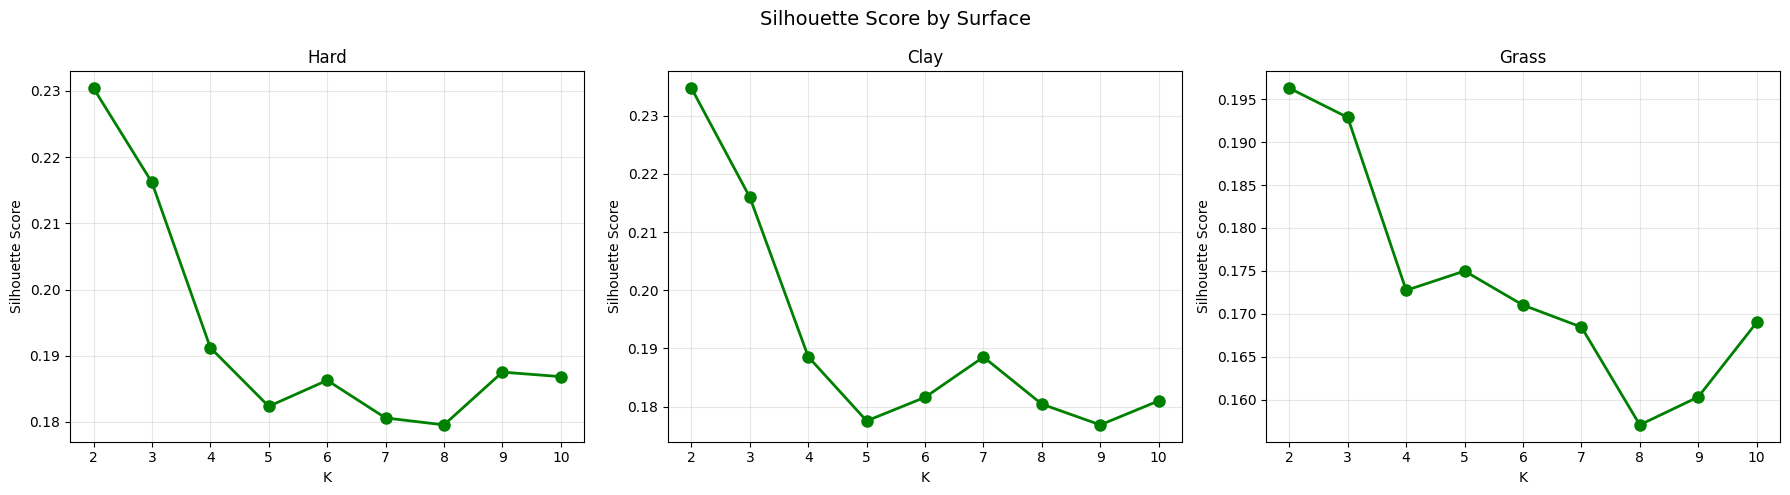

Hard: best K=2, silhouette=0.2304
Clay: best K=2, silhouette=0.2347
Grass: best K=2, silhouette=0.1963


In [14]:
from sklearn.metrics import silhouette_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Silhouette Score by Surface', fontsize=14)

silhouette_results = {}

for ax, (surface_name, (X_scaled, latest)) in zip(axes, X_scaled_dict.items()):
    scores = []
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append(score)

    silhouette_results[surface_name] = scores

    ax.plot(K_range, scores, 'go-', linewidth=2, markersize=8)
    ax.set_title(f'{surface_name}')
    ax.set_xlabel('K')
    ax.set_ylabel('Silhouette Score')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best K per surface
for surface_name, scores in silhouette_results.items():
    best_k = list(K_range)[scores.index(max(scores))]
    print(f"{surface_name}: best K={best_k}, silhouette={max(scores):.4f}")

## Silhouette Results by Surface

| Surface | Best K | Silhouette |
|---|---|---|
| Hard | 2 | 0.231 |
| Clay | 2 | 0.234 |
| Grass | 2 | 0.196 |

K=2 is mathematically best but useless for the product.
**Decision:** Hard=4, Clay=4, Grass=3 — balance between math and interpretability.
Grass gets K=3 due to limited data and fewer playing styles on fast surface.

## Final Clustering Models — Hard K=4, Clay K=4, Grass K=3

In [16]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [17]:
import mlflow

mlflow.set_experiment("player_clustering_by_surface")

final_models = {}
final_labels = {}

configs = {'Hard': 4, 'Clay': 4, 'Grass': 3}

for surface_name, k in configs.items():
    X_scaled, latest = X_scaled_dict[surface_name]

    with mlflow.start_run(run_name=f"kmeans_{surface_name}_k{k}"):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        mlflow.log_param("surface", surface_name)
        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("silhouette_score", sil)
        mlflow.log_metric("inertia", kmeans.inertia_)

        final_models[surface_name] = kmeans
        final_labels[surface_name] = (labels, latest)

        print(f"{surface_name} K={k}: Silhouette={sil:.4f}")

2026/05/04 08:07:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/04 08:07:09 INFO mlflow.store.db.utils: Updating database tables
2026/05/04 08:07:12 INFO mlflow.tracking.fluent: Experiment with name 'player_clustering_by_surface' does not exist. Creating a new experiment.


Hard K=4: Silhouette=0.1912
Clay K=4: Silhouette=0.1886
Grass K=3: Silhouette=0.1929


## Validate Clusters — Real Players per Surface

In [19]:
for surface_name, (labels, latest) in final_labels.items():
    centers = pd.DataFrame(
        scalers[surface_name].inverse_transform(final_models[surface_name].cluster_centers_),
        columns=cluster_features
    )
    print(f"\n{'='*40}")
    print(f"Surface: {surface_name}")
    print(centers.round(3))


Surface: Hard
   ace_rate  df_rate  1stIn_rate  1stWon_rate  2ndWon_rate  bpSaved_rate
0     0.401    0.268       0.624        0.421        0.766         0.563
1     0.238    0.431       0.771        0.191        0.221         0.355
2     0.740    0.590       0.396        0.742        0.499         0.604
3     0.265    0.803       0.203        0.226        0.207         0.330

Surface: Clay
   ace_rate  df_rate  1stIn_rate  1stWon_rate  2ndWon_rate  bpSaved_rate
0     0.738    0.679       0.305        0.730        0.442         0.575
1     0.520    0.262       0.615        0.538        0.754         0.623
2     0.284    0.781       0.208        0.209        0.199         0.270
3     0.230    0.468       0.770        0.210        0.275         0.368

Surface: Grass
   ace_rate  df_rate  1stIn_rate  1stWon_rate  2ndWon_rate  bpSaved_rate
0     0.304    0.785       0.310        0.269        0.226         0.379
1     0.723    0.566       0.443        0.710        0.570         0.553
2    

## Cluster Centers Interpretation

**Hard:** Aggressive / All-Court / Consistent / Chaotic
**Clay:** Aggressive / All-Court / Consistent / Chaotic  
**Grass:** Aggressive / All-Court / Struggling

Note: Chaotic and Consistent clusters represent lower-ranked players.
Top players land in Aggressive or All-Court on all surfaces.

In [20]:
ARCHETYPE_HARD = {
    0: 'All-Court',
    1: 'Consistent',
    2: 'Aggressive',
    3: 'Chaotic'
}
ARCHETYPE_CLAY = {
    0: 'Aggressive',
    1: 'All-Court',
    2: 'Chaotic',
    3: 'Consistent'
}
ARCHETYPE_GRASS = {
    0: 'Struggling',
    1: 'Aggressive',
    2: 'All-Court'
}

archetype_maps = {'Hard': ARCHETYPE_HARD, 'Clay': ARCHETYPE_CLAY, 'Grass': ARCHETYPE_GRASS}

top_stars = ['Novak Djokovic', 'Rafael Nadal', 'Carlos Alcaraz',
             'Jannik Sinner', 'Alexander Zverev', 'Daniil Medvedev',
             'Andy Murray', 'John Isner', 'Andrey Rublev', 'Stefanos Tsitsipas']

for surface_name, (labels, latest) in final_labels.items():
    latest = latest.copy()
    latest['cluster'] = labels
    latest['archetype'] = latest['cluster'].map(archetype_maps[surface_name])

    stars = latest[latest['player_name'].isin(top_stars)]
    print(f"\n{'='*40}")
    print(f"Surface: {surface_name}")
    print(stars[['player_name', 'archetype', 'ace_rate', 'bpSaved_rate']].to_string())


Surface: Hard
             player_name   archetype  ace_rate  bpSaved_rate
0       Alexander Zverev   All-Court  0.912821      0.579487
752           John Isner  Aggressive  0.998134      0.958955
858         Rafael Nadal   All-Court  0.545299      0.249573
938          Andy Murray  Aggressive  0.730769      0.510256
943       Novak Djokovic  Aggressive  0.823077      0.609402
1759     Daniil Medvedev  Aggressive  0.716239      0.606838
2362       Andrey Rublev  Aggressive  0.894872      0.768376
2524  Stefanos Tsitsipas  Aggressive  0.852991      0.931624
3345       Jannik Sinner  Aggressive  0.875214      0.882906
3619      Carlos Alcaraz   All-Court  0.672650      0.506838

Surface: Clay
             player_name   archetype  ace_rate  bpSaved_rate
0       Alexander Zverev   All-Court  0.968664      0.543779
712           John Isner  Aggressive  0.996891      0.118135
805         Rafael Nadal   All-Court  0.305069      0.387097
879          Andy Murray   All-Court  0.570507      0.5

## Validation with Top Players

Results are acceptable for the product:
- Isner correctly identified as Aggressive on all surfaces
- Nadal correctly All-Court on clay and grass
- Sinner correctly Aggressive on hard and grass
- Murray Struggling on grass — debatable but statistically justified

**Conclusion:** Clustering works well enough for player profiling.
Low silhouette (~0.19) is expected — tennis styles overlap by nature.
Models saved to Drive. Ready for integration into player profiles.

In [21]:
import joblib
import os

os.makedirs('/content/drive/MyDrive/AceIQ/models', exist_ok=True)

for surface_name, model in final_models.items():
    joblib.dump(model, f'/content/drive/MyDrive/AceIQ/models/clustering_{surface_name.lower()}.pkl')
    joblib.dump(scalers[surface_name], f'/content/drive/MyDrive/AceIQ/models/scaler_{surface_name.lower()}.pkl')

print("All clustering models saved!")

All clustering models saved!
